# Lab 1 - Fine-tuning Pipeline

Questo notebook copre l'**Exercise 1.3: A Fine-tuning Baseline** e prepara l'**Exercise 2: Pipeline Consolidation**.

L'obiettivo e' passare dalla baseline stabile basata su feature ResNet-18 + SVM a una baseline di fine-tuning semplice, riproducibile e spiegabile. In questa fase alleniamo solo il classificatore finale della ResNet-18, mantenendo congelato il backbone pre-addestrato su ImageNet.

## Richieste dell'esercizio

L'Exercise 1.3 richiede di:

- caricare una ResNet-18 pre-addestrata;
- sostituire il classificatore finale con una nuova testa per le 43 classi GTSRB;
- allenare il modello per alcune epoche;
- monitorare non solo il training loss, ma anche la validation loss su uno split indipendente;
- valutare se il solo fine-tuning della testa finale migliora la baseline precedente.

Per evitare notebook ripetitivi, gli esperimenti vecchi con diverse loss e optimizer vengono riassunti in una tabella. La run eseguita qui e' solo quella piu' significativa: `Adam + CrossEntropy`, cioe' la migliore tra le prove head-only precedenti.

In [2]:
from pathlib import Path
import sys

import pandas as pd
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from dla_lab1.config import experiment_config, load_config
from dla_lab1.data import build_dataloaders, missing_classes_in_split
from dla_lab1.evaluate import classification_metrics, history_to_frame, predict
from dla_lab1.experiments import batch_size_for, run_finetuning
from dla_lab1.models import build_classifier, count_parameters
from dla_lab1.seed import seed_everything
from dla_lab1.train import configure_torch_for_hardware, resolve_device
from dla_lab1.visualize import plot_training_history

config = load_config(ROOT / "config" / "config.yaml")
seed_everything(int(config["project"]["seed"]))

device = resolve_device(config["project"].get("device", "auto"))
configure_torch_for_hardware(device, bool(config["hardware"].get("allow_tf32", True)))

print(f"Project root: {ROOT}")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Project root: c:\Users\checc\OneDrive\Desktop\DLA\DLA_Lab\DLA_1
Device: cuda
PyTorch: 2.10.0
GPU: NVIDIA GeForce RTX 2050


## Configurazione della run

Per mantenere un buon rapporto tra costo e prestazioni sul PC disponibile, questa run usa:

- **ResNet-18**, non un modello piu' pesante;
- **backbone congelato**, quindi si addestra solo la `fc` finale;
- **batch size 64**, uguale alle prove vecchie e adatto a una GPU da 4 GB;
- **10 epoche**, sufficienti per una baseline senza rendere il notebook troppo lento;
- **learning rate 0.001**, coerente con lo screening preliminare;
- **AMP attivo** quando si usa CUDA, per velocizzare il training e ridurre memoria.

In [3]:
EXPERIMENT_NAME = "ex1_3_head_only_adam_ce"
exp_cfg = experiment_config(config, EXPERIMENT_NAME)
training_cfg = exp_cfg["training"]
batch_size = batch_size_for(config, exp_cfg["experiment"]["batch_size_key"])

run_setup = pd.DataFrame([
    ["experiment", EXPERIMENT_NAME],
    ["model", exp_cfg["model"]["name"]],
    ["weights", exp_cfg["model"].get("weights")],
    ["freeze_backbone", exp_cfg["model"].get("freeze_backbone")],
    ["unfreeze_layer4", exp_cfg["model"].get("unfreeze_layer4")],
    ["loss", training_cfg["loss"]],
    ["optimizer", training_cfg["optimizer"]],
    ["learning_rate", training_cfg["learning_rate"]],
    ["batch_size", batch_size],
    ["epochs", training_cfg["epochs"]],
    ["scheduler", training_cfg["scheduler"]],
    ["use_amp", training_cfg["use_amp"] and device.type == "cuda"],
], columns=["parameter", "value"])

run_setup

,parameter,value
0,experiment,ex1_3_head_only_adam_ce
1,model,resnet18
2,weights,DEFAULT
3,freeze_backbone,True
4,unfreeze_layer4,False
5,loss,CrossEntropy
6,optimizer,Adam
7,learning_rate,0.001
8,batch_size,64
9,epochs,10


## Validation split

Il test set ufficiale non viene usato per scegliere gli iperparametri. Per monitorare overfitting e stabilita' della run, dividiamo il training set in train e validation.

Lo split e' costruito per classe e per piccoli gruppi consecutivi di immagini, per ridurre il rischio che immagini quasi identiche finiscano sia in train sia in validation. Qui controlliamo esplicitamente che la validation contenga almeno un elemento per ognuna delle 43 classi.

In [ ]:
loaders = build_dataloaders(
    data_root=ROOT / config["paths"]["data_root"],
    image_size=int(config["dataset"]["image_size"]),
    batch_size=batch_size,
    val_split=float(config["dataset"]["val_split"]),
    track_size=int(config["dataset"]["track_size"]),
    seed=int(config["project"]["seed"]),
    num_workers=int(config["dataset"]["num_workers"] = 4),
    pin_memory=bool(config["dataset"]["pin_memory"]),
    augmentation="none",
)

split_summary = loaders["split_summary"]
missing_val_classes = missing_classes_in_split(split_summary, "val_count")
missing_train_classes = missing_classes_in_split(split_summary, "train_count")

split_check = pd.DataFrame([
    ["train samples", int(split_summary["train_count"].sum())],
    ["validation samples", int(split_summary["val_count"].sum())],
    ["classes in train", int((split_summary["train_count"] > 0).sum())],
    ["classes in validation", int((split_summary["val_count"] > 0).sum())],
    ["missing train classes", missing_train_classes],
    ["missing validation classes", missing_val_classes],
    ["min validation samples per class", int(split_summary["val_count"].min())],
    ["max validation samples per class", int(split_summary["val_count"].max())],
], columns=["check", "value"])

assert not missing_train_classes, f"Classi mancanti nel train split: {missing_train_classes}"
assert not missing_val_classes, f"Classi mancanti nella validation: {missing_val_classes}"

split_check

,check,value
0,train samples,20820
1,validation samples,5820
2,classes in train,43
3,classes in validation,43
4,missing train classes,[]
5,missing validation classes,[]
6,min validation samples per class,30
7,max validation samples per class,300


In [5]:
split_summary.head(10)

,class_id,train_count,val_count,total_count,val_ratio
0,0,120,30,150,0.200000
1,1,1200,300,1500,0.200000
2,2,1200,300,1500,0.200000
3,3,750,210,960,0.218750
4,4,1050,270,1320,0.204545
5,5,990,270,1260,0.214286
6,6,240,60,300,0.200000
7,7,750,210,960,0.218750
8,8,750,210,960,0.218750
9,9,780,210,990,0.212121


## Screening preliminare delle prove head-only

Nel vecchio notebook erano state provate diverse combinazioni di optimizer e loss, sempre con backbone congelato e solo classificatore finale addestrabile. Non rilanciamo tutte le 9 prove: le riportiamo come screening preliminare e poi manteniamo solo la configurazione piu' significativa.

In [6]:
screening_results = pd.DataFrame([
    ["Adam_CrossEntropy", "CrossEntropy", "Adam", 0.5273, 8],
    ["AdamW_CrossEntropy", "CrossEntropy", "AdamW", 0.5240, 5],
    ["SGD_CrossEntropy", "CrossEntropy", "SGD", 0.4463, 9],
    ["Adam_WeightedCrossEntropy", "WeightedCrossEntropy", "Adam", 0.5139, 7],
    ["AdamW_WeightedCrossEntropy", "WeightedCrossEntropy", "AdamW", 0.5135, 10],
    ["SGD_WeightedCrossEntropy", "WeightedCrossEntropy", "SGD", 0.3552, 10],
    ["Adam_FocalLoss", "FocalLoss", "Adam", 0.4860, 6],
    ["AdamW_FocalLoss", "FocalLoss", "AdamW", 0.4925, 10],
    ["SGD_FocalLoss", "FocalLoss", "SGD", 0.3322, 10],
], columns=["Experiment", "Loss", "Optimizer", "Best Val Accuracy", "Best Epoch"])

screening_results.sort_values("Best Val Accuracy", ascending=False)

,Experiment,Loss,Optimizer,Best Val Accuracy,Best Epoch
0,Adam_CrossEntropy,CrossEntropy,Adam,0.5273,8
1,AdamW_CrossEntropy,CrossEntropy,AdamW,0.5240,5
3,Adam_WeightedCrossEntropy,WeightedCrossEntropy,Adam,0.5139,7
4,AdamW_WeightedCrossEntropy,WeightedCrossEntropy,AdamW,0.5135,10
7,AdamW_FocalLoss,FocalLoss,AdamW,0.4925,10
6,Adam_FocalLoss,FocalLoss,Adam,0.4860,6
2,SGD_CrossEntropy,CrossEntropy,SGD,0.4463,9
5,SGD_WeightedCrossEntropy,WeightedCrossEntropy,SGD,0.3552,10
8,SGD_FocalLoss,FocalLoss,SGD,0.3322,10


Il risultato dello screening e' chiaro: `Adam + CrossEntropy` e' la migliore configurazione head-only, con validation accuracy pari a **0.5273**. `AdamW + CrossEntropy` e' molto vicino, mentre SGD converge peggio con lo stesso learning rate e lo stesso numero di epoche.

WeightedCrossEntropy e FocalLoss erano motivate dallo sbilanciamento tra classi osservato nell'EDA, ma in questa configurazione non migliorano il risultato. Questo suggerisce che il limite principale non sia solo lo sbilanciamento, ma anche il fatto che le feature ImageNet congelate non siano ancora abbastanza adattate al dominio dei segnali stradali.

## Controllo del modello

Prima di allenare, verifichiamo che la ResNet-18 abbia davvero il backbone congelato e che siano addestrabili solo i parametri della nuova testa finale.

In [7]:
model = build_classifier(
    model_name=exp_cfg["model"]["name"],
    num_classes=int(config["project"]["num_classes"]),
    weights=exp_cfg["model"].get("weights", "DEFAULT"),
    freeze_backbone=bool(exp_cfg["model"].get("freeze_backbone", True)),
    unfreeze_layer4=bool(exp_cfg["model"].get("unfreeze_layer4", False)),
)

pd.DataFrame([count_parameters(model)])

,total,trainable
0,11198571,22059


## Training della baseline head-only

Questa e' la run principale dell'Exercise 1.3. Il training loop non e' scritto manualmente nel notebook: viene richiamato da `src/dla_lab1`, in modo che la pipeline sia riutilizzabile e configurabile.

La validation accuracy viene usata per salvare il miglior checkpoint. Se la validation non migliora, l'early stopping evita di sprecare tempo inutilmente.

In [8]:
result = run_finetuning(config, EXPERIMENT_NAME, root=ROOT)
history = history_to_frame(result["history"])
history

  0%|          | 0/326 [00:09<?, ?it/s]

  0%|          | 0/91 [00:08<?, ?it/s]

Epoch 01 | lr=1.00e-03 | train_loss=1.7443 train_acc=0.5175 | val_loss=2.0872 val_acc=0.4297


  0%|          | 0/326 [00:08<?, ?it/s]

  0%|          | 0/91 [00:09<?, ?it/s]

...

Epoch 09 | lr=1.00e-05 | train_loss=0.6032 train_acc=0.8211 | val_loss=2.1018 val_acc=0.4746


  0%|          | 0/326 [00:09<?, ?it/s]

  0%|          | 0/91 [00:09<?, ?it/s]

Epoch 10 | lr=1.00e-05 | train_loss=0.6042 train_acc=0.8224 | val_loss=2.0852 val_acc=0.4735
Early stopping at epoch 10.


,epoch,train_loss,train_acc,val_loss,val_acc,learning_rate
0,1,1.744337,0.517483,2.087210,0.429725,0.00100
1,2,0.988288,0.711191,2.060829,0.452577,0.00100
2,3,0.818380,0.752498,2.083187,0.457732,0.00100
3,4,0.734424,0.777233,2.193421,0.451890,0.00100
4,5,0.633942,0.813160,2.085414,0.478179,0.00010
5,6,0.624741,0.815466,2.089019,0.472680,0.00010
6,7,0.624248,0.815226,2.111028,0.469588,0.00010
7,8,0.618714,0.816907,2.106734,0.474914,0.00010
8,9,0.603214,0.821134,2.101801,0.474570,0.00001
9,10,0.604205,0.822430,2.085159,0.473540,0.00001


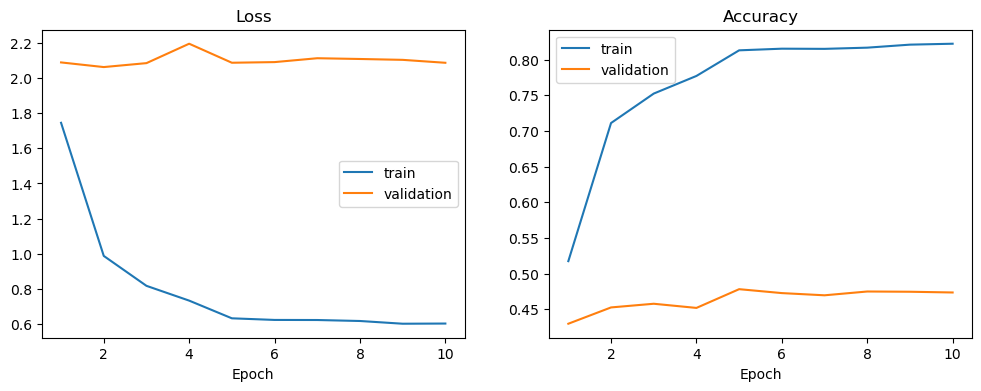

In [9]:
plot_training_history(history);

## Valutazione su validation

Valutiamo il miglior checkpoint sulla validation. Questa valutazione serve a capire se la baseline di fine-tuning head-only e' competitiva rispetto alla baseline precedente feature extractor + SVM.

In [10]:
y_true_val, y_pred_val = predict(result["model"], result["loaders"]["val"], result["device"])
val_metrics = classification_metrics(y_true_val.numpy(), y_pred_val.numpy())

best_row = history.loc[history["val_acc"].idxmax()]
validation_summary = pd.DataFrame([
    ["best_epoch", int(best_row["epoch"])],
    ["best_val_accuracy_from_training", float(best_row["val_acc"])],
    ["validation_accuracy_recomputed", float(val_metrics["accuracy"])],
    ["baseline_svm_test_accuracy_previous_notebook", 0.6412],
], columns=["metric", "value"])

validation_summary

,metric,value
0,best_epoch,5.000000
1,best_val_accuracy_from_training,0.478179
2,validation_accuracy_recomputed,0.478179
3,baseline_svm_test_accuracy_previous_notebook,0.641200


In [11]:
print(val_metrics["classification_report"])

              precision    recall  f1-score   support

           0       0.60      0.20      0.30        30
           1       0.34      0.33      0.33       300
           2       0.25      0.32      0.28       300
           3       0.48      0.50      0.49       210
           4       0.42      0.38      0.40       270
           5       0.41      0.39      0.40       270
           6       0.57      0.92      0.71        60
           7       0.51      0.40      0.45       210
           8       0.38      0.38      0.38       210
           9       0.47      0.48      0.47       210
          10       0.47      0.62      0.54       270
          11       0.31      0.43      0.36       180
          12       0.77      0.83      0.80       300
          13       0.84      0.87      0.86       300
          14       0.90      0.95      0.93       120
          15       0.90      0.84      0.87        90
          16       0.59      0.57      0.58        60
          17       0.86    

## Conclusione Exercise 1.3

Questa sezione rispetta le richieste dell'esercizio: carica una ResNet-18 pre-addestrata, sostituisce la testa finale, allena il modello su GTSRB e monitora sia training sia validation.

La scelta `Adam + CrossEntropy` viene mantenuta perche' era la migliore tra le prove head-only precedenti. Il confronto atteso e' che questa baseline resti sotto la baseline feature extraction + SVM, che nel notebook precedente aveva raggiunto circa **0.6412** di accuracy sul test ufficiale. Il risultato e' comunque utile: mostra che allenare solo la testa finale non basta ad adattare bene le feature ImageNet al task GTSRB.

Il passo successivo, coerente con la traccia del professore, sara' sbloccare una parte del backbone, ad esempio `layer4`, e confrontare il miglioramento mantenendo la stessa pipeline configurabile.

## Note sulle funzioni usate

Le funzioni richiamate nel notebook sono commentate direttamente nei file `.py` dentro `src/dla_lab1`. In particolare:

- `build_dataloaders` crea train, validation e test loader;
- `split_class_summary` controlla la distribuzione delle classi nello split;
- `missing_classes_in_split` verifica se mancano classi in train o validation;
- `build_classifier` costruisce la ResNet-18 adattata a 43 classi;
- `run_finetuning` esegue l'intera pipeline di training da configurazione;
- `train_model` gestisce training, validation, checkpoint ed early stopping;
- `history_to_frame` converte la storia del training in tabella;
- `predict` e `classification_metrics` servono per la valutazione finale.